## Fake & Real News Detection:
- Task: Text Classification Using Gensim Word2Vec
- **Steps**
    - Loading Word2Vec embeddings
    - Preprocessing text
    - Training / loading a Gradient Boosting classifier
    - Evaluating and making predictions
    - Saving / loading the model with pickle.

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import gensim.downloader as api
import spacy
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix

In [ ]:
# Load pretrained Word2Vec and spaCy models
print("Loading Word2Vec model (word2vec-google-news-300)...")
wv = api.load("word2vec-google-news-300")

print("Loading spaCy model (en_core_web_sm)...")
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise OSError(
        "spaCy model 'en_core_web_sm' not found. "
        "Please run: python -m spacy download en_core_web_sm"
    )

Loading Word2Vec model (word2vec-google-news-300)...
[====================================--------------] 72.1% 1199.6/1662.8MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



[=======================================-----------] 78.5% 1304.8/1662.8MB downloaded

In [ ]:
# Check
wv_King = wv["King"]
wv_Queen = wv["Queen"]

wv_King.shape, wv_Queen.shape

In [ ]:
# Preprocessing and vectorization helper
def preprocess_and_vectorize(text: str) -> np.ndarray:
    """Preprocess text and convert to a 300-dim vector using Word2Vec.
    Steps:
    - Tokenize with spaCy
    - Remove stop words and punctuation
    - Lemmatize tokens
    - Take mean of Word2Vec embeddings for remaining tokens
    """
    if not text or not isinstance(text, str):
        return np.zeros(300)

    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    if not filtered_tokens:
        return np.zeros(300)

    try:
        return wv.get_mean_vector(filtered_tokens, pre_normalize=False)
    except KeyError:
        # If none of the tokens are in the Word2Vec vocabulary
        return np.zeros(300)

In [ ]:
# Load dataset
# DATA_PATH = "fake_and_real_news.csv" # Divya
DATA_PATH = "/kaggle/input/datasets/divyasreeketha/fake-and-real-news/fake_and_real_news.csv"

df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)

df.head()

In [ ]:
df['label'].value_counts()

In [ ]:
# Encode labels {Map 'Fake' -> 0, 'Real' -> 1}
df["label_num"] = df["label"].map({"Fake": 0, "Real": 1})

df[["label", "label_num"]].head()

In [9]:
# Vectorize all texts
def vectorize_series(text_series: pd.Series) -> np.ndarray:
    return np.stack(text_series.apply(preprocess_and_vectorize).values)

print("Vectorizing texts... (this may take several minutes)")
X = vectorize_series(df["Text"])
y = df["label_num"].values

X.shape, y.shape

((9900, 300), (9900,))

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2022,
    stratify=y,
)

X_train.shape, X_test.shape

((7920, 300), (1980, 300))

In [11]:
# Train or load classifier with pickle
# MODEL_PATH = "news_classifier.pkl" # Divya
MODEL_PATH = "/kaggle/working/news_classifier.pkl"

clf: GradientBoostingClassifier

if os.path.exists(MODEL_PATH):
    print(f"Loading existing model from {MODEL_PATH} (no retraining)...")
    with open(MODEL_PATH, "rb") as f:
        clf = pickle.load(f)
else:
    print("No existing model found. Training a new GradientBoostingClassifier...")
    clf = GradientBoostingClassifier()
    clf.fit(X_train, y_train)

    # Evaluate on test set
    y_pred = clf.predict(X_test)
    print("\nModel performance on test set:")
    print(classification_report(y_test, y_pred))

    # Save the trained model
    with open(MODEL_PATH, "wb") as f:
        pickle.dump(clf, f)
    print(f"\nModel saved to {MODEL_PATH}")

No existing model found. Training a new GradientBoostingClassifier...

Model performance on test set:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1000
           1       0.97      0.99      0.98       980

    accuracy                           0.98      1980
   macro avg       0.98      0.98      0.98      1980
weighted avg       0.98      0.98      0.98      1980


Model saved to /kaggle/working/news_classifier.pkl


In [12]:
# Test
def classify_text(text: str):
    """Classify a single text as Real or Fake using the loaded model."""
    vec = preprocess_and_vectorize(text).reshape(1, -1)
    pred = clf.predict(vec)[0]
    proba = clf.predict_proba(vec)[0]
    confidence = proba[pred]
    label = "Real" if pred == 1 else "Fake"
    return {
        "label": label,
        "prediction": int(pred),
        "confidence": float(confidence),
    }

# Example predictions
examples = [
    "The government announced a new policy today to reduce emissions by 2030.",
    "Scientists confirm that drinking two liters of cola a day cures all diseases.",
]

for text in examples:
    result = classify_text(text)
    print("Text:", text)
    print("Prediction:", result["label"], "(confidence: {:.2%})".format(result["confidence"]))
    print("-" * 80)

Text: The government announced a new policy today to reduce emissions by 2030.
Prediction: Real (confidence: 98.16%)
--------------------------------------------------------------------------------
Text: Scientists confirm that drinking two liters of cola a day cures all diseases.
Prediction: Real (confidence: 91.92%)
--------------------------------------------------------------------------------


Text(95.72222222222221, 0.5, 'Truth')

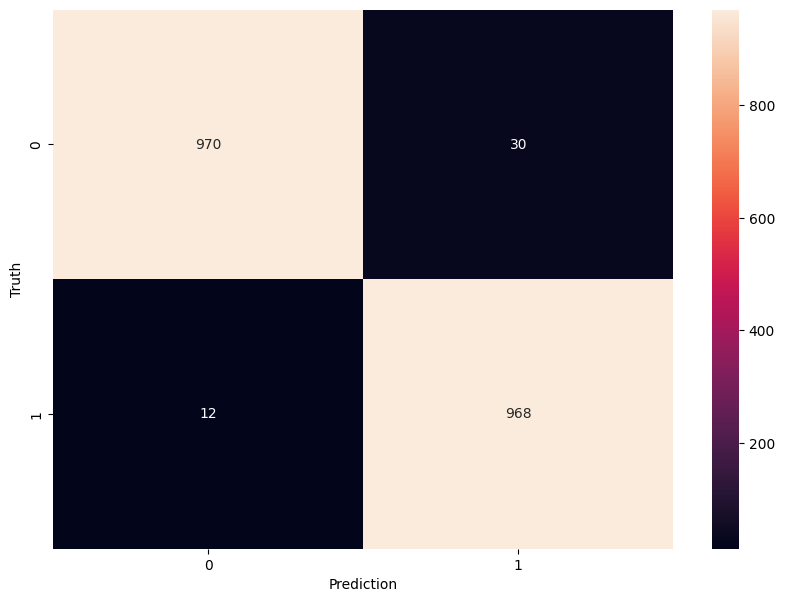

In [13]:
cm = confusion_matrix(y_test, y_pred)
cm

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')